In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Better plot appearance
plt.rcParams["figure.figsize"] = (8,5)
sns.set_style("whitegrid")

In [2]:
data=pd.read_csv("/content/titanic test.csv")

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.shape

(891, 12)

In [5]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
data.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [10]:
data['Survived'].unique()

array([0, 1])

In [11]:
data['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [12]:
(data.isnull().sum()/len(data))*100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


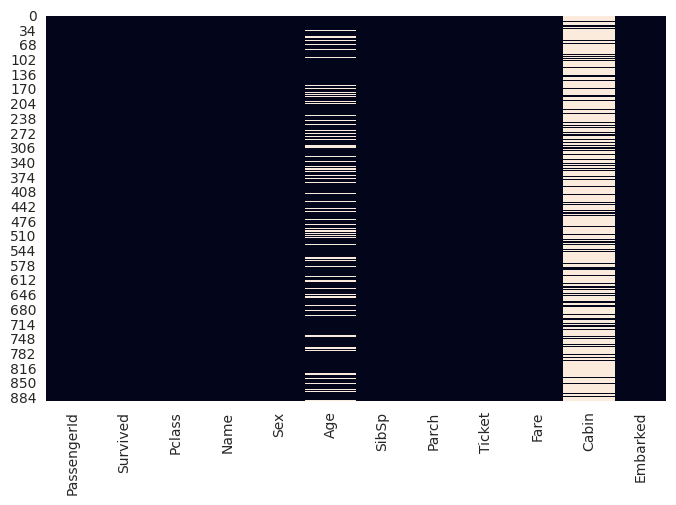

In [13]:
sns.heatmap(data.isnull(), cbar=False)
plt.show()

In [14]:
data["Age"] = data["Age"].fillna(data["Age"].mean())

In [15]:
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

In [16]:
data.duplicated().sum()

np.int64(0)

In [17]:
data["Age"] = pd.to_numeric(data["Age"])

In [18]:
data["Sex"] = data["Sex"].astype("category")

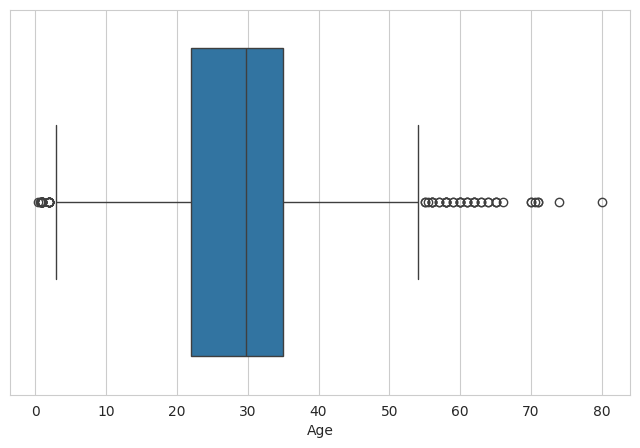

In [19]:
sns.boxplot(x=data["Age"])
plt.show()

In [20]:
Q1 = data["Age"].quantile(0.25)
Q3 = data["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

data = data[(data["Age"] >= lower) & (data["Age"] <= upper)]

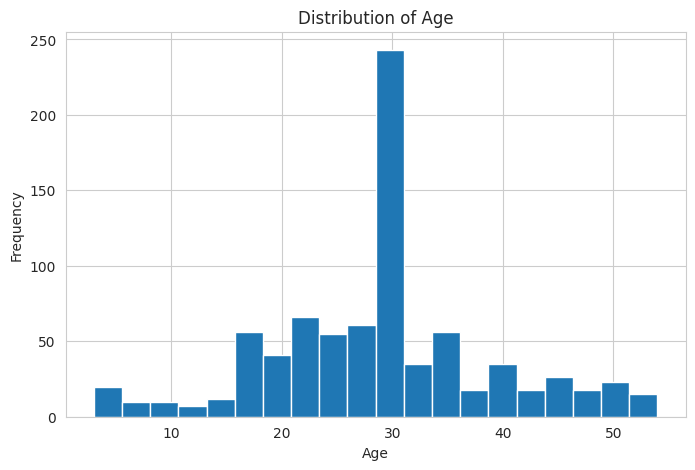

In [21]:
plt.hist(data["Age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()

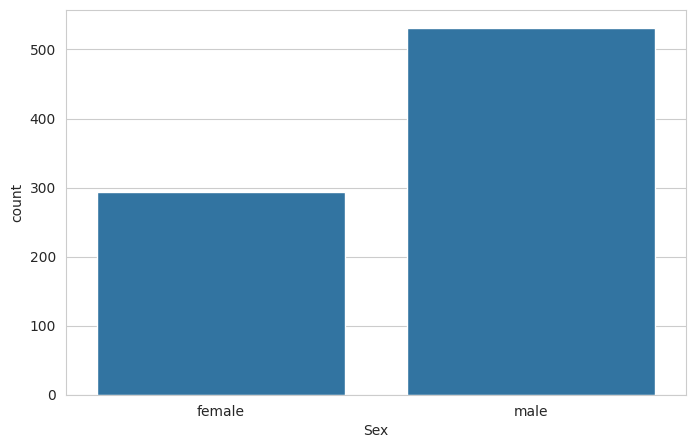

In [23]:
sns.countplot(x="Sex", data=data)
plt.show()

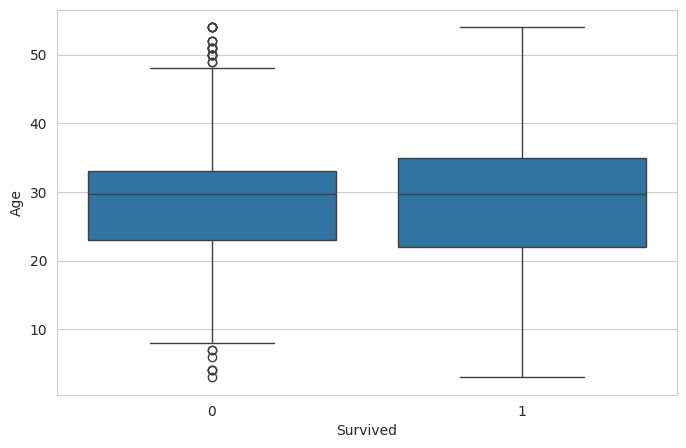

In [24]:
sns.boxplot(x="Survived", y="Age", data=data)
plt.show()

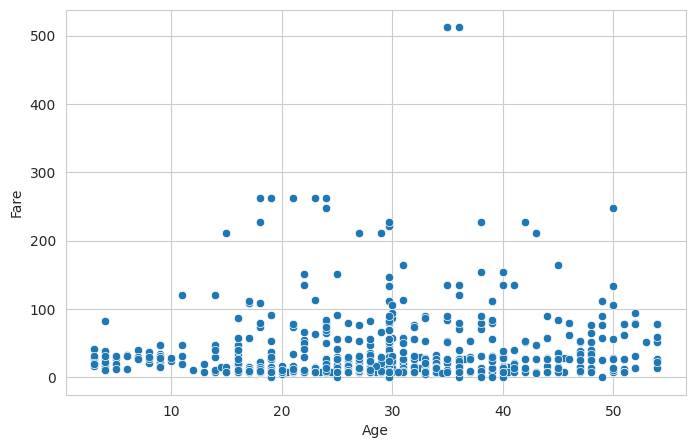

In [25]:
sns.scatterplot(x="Age", y="Fare", data=data)
plt.show()

In [26]:
numeric_data = data.select_dtypes(include=np.number)

corr = numeric_data.corr()

corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.018151,-0.034032,0.048444,-0.053075,-0.006142,0.015231
Survived,-0.018151,1.000000,-0.367774,-0.027320,-0.030860,0.074199,0.269672
Pclass,-0.034032,-0.367774,1.000000,-0.286128,0.057760,0.018742,-0.552684
Age,0.048444,-0.027320,-0.286128,1.000000,-0.182124,-0.131052,0.091278
SibSp,-0.053075,-0.030860,0.057760,-0.182124,1.000000,0.408487,0.166625
Parch,-0.006142,0.074199,0.018742,-0.131052,0.408487,1.000000,0.190001
Fare,0.015231,0.269672,-0.552684,0.091278,0.166625,0.190001,1.000000


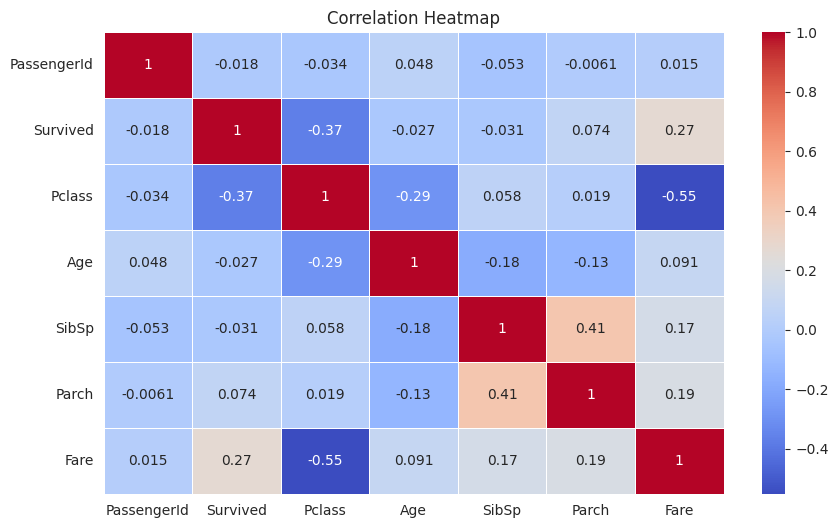

In [27]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

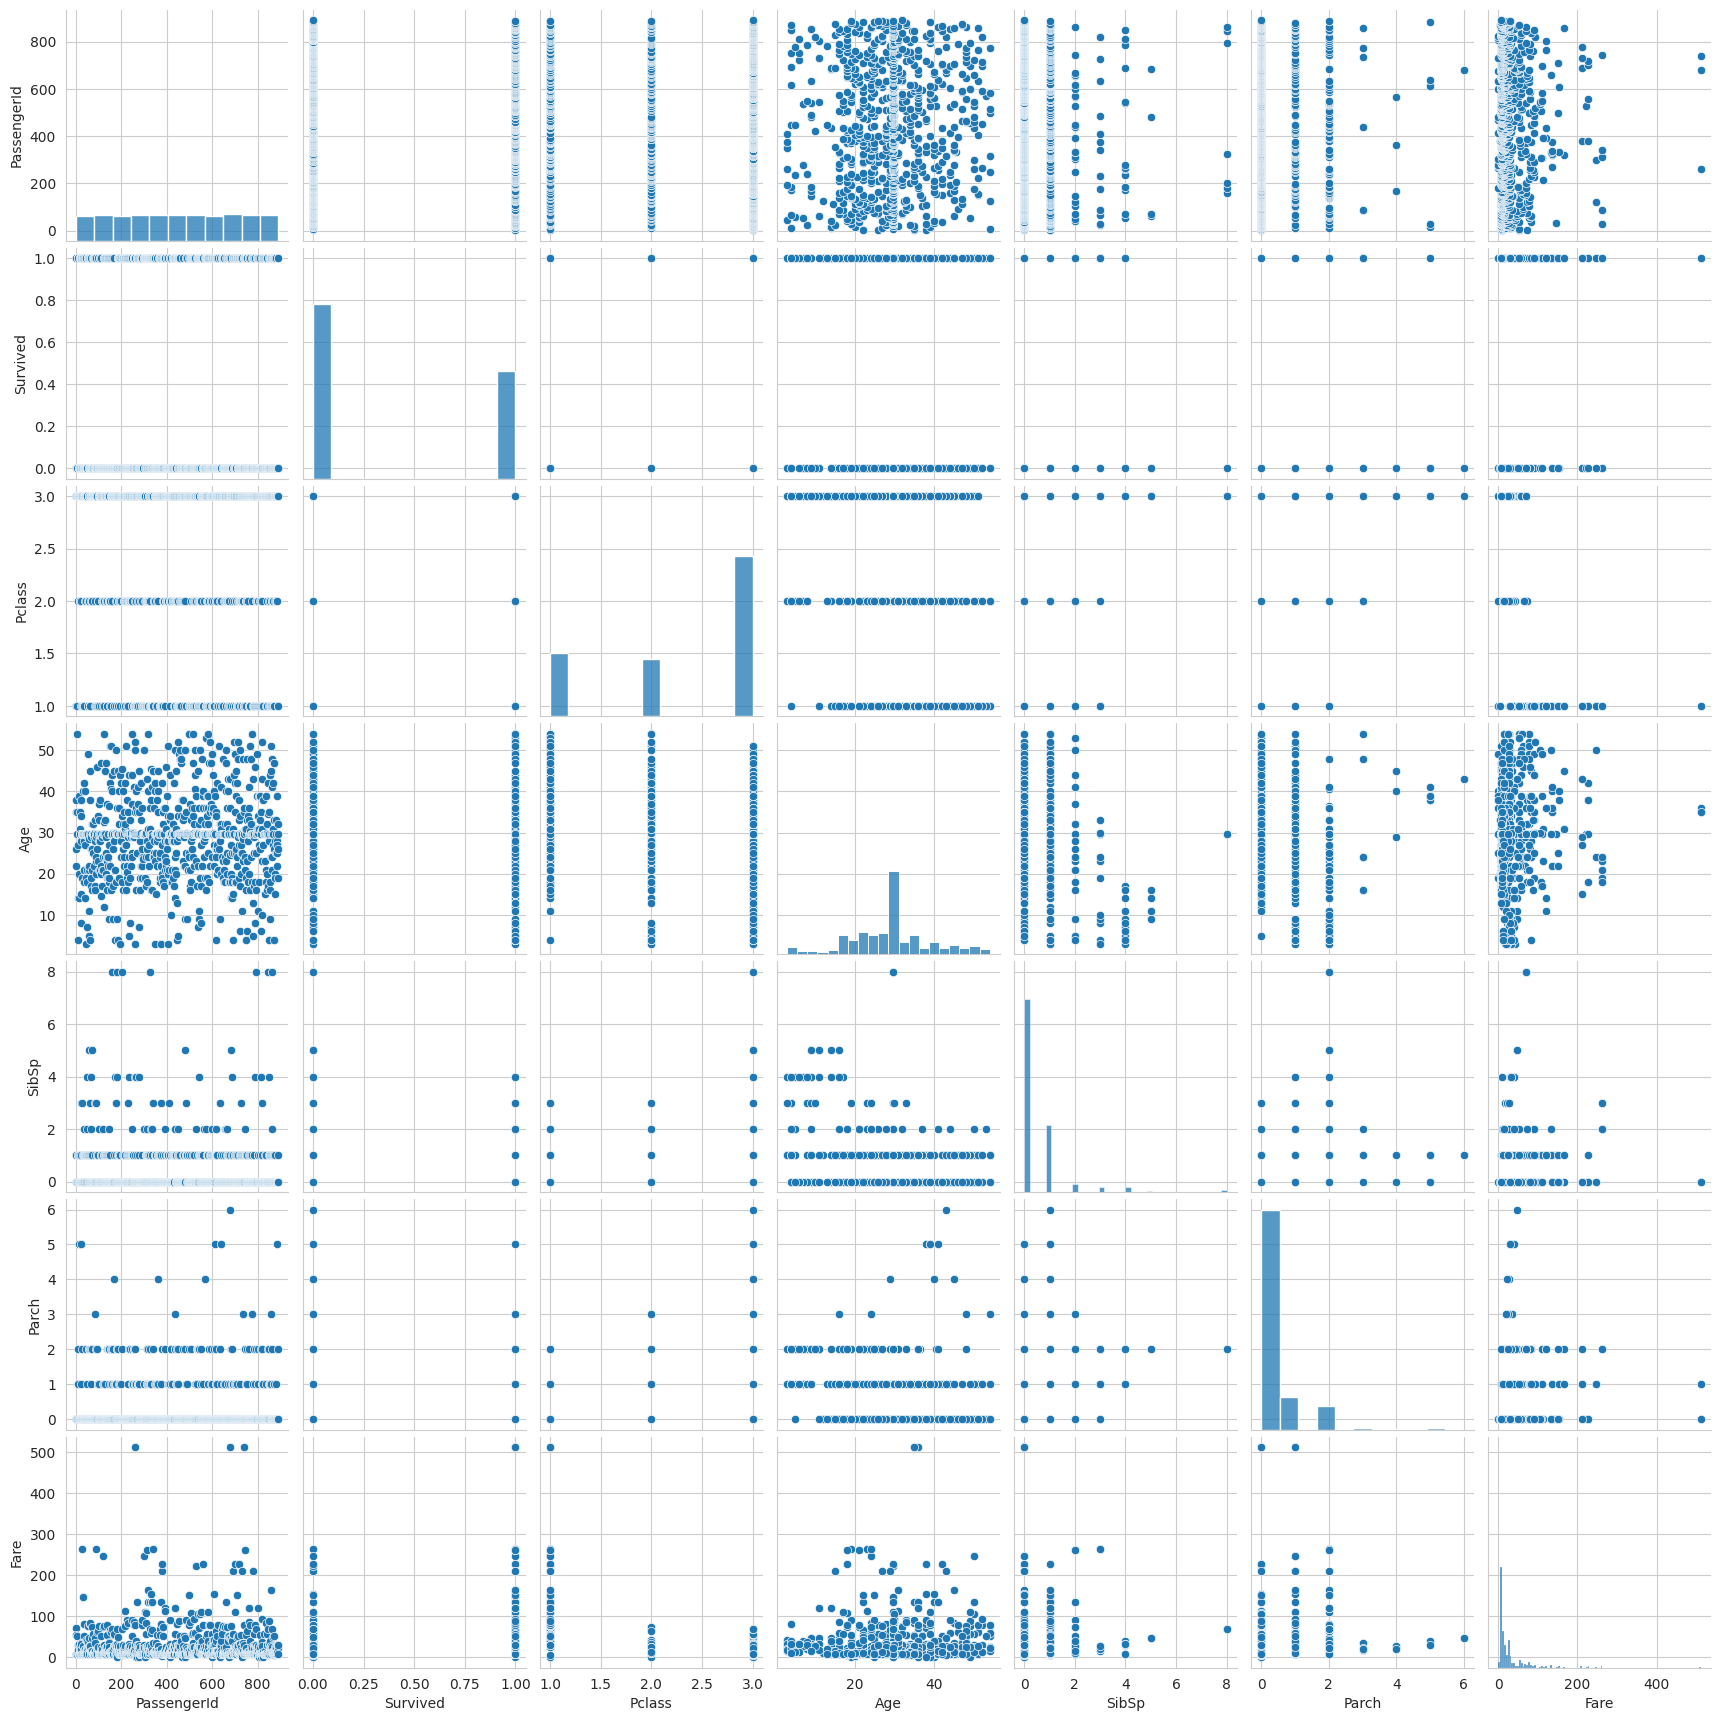

In [28]:
sns.pairplot(data)
plt.show()

In [29]:
data.to_csv("cleaned_dataset.csv", index=False)